# Project 1 — Random Forest
## Employee Attrition Prediction

Predicting whether an employee will leave the company based on satisfaction score, monthly salary, tenure, overtime hours, and number of projects.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report,
                              roc_auc_score, roc_curve)
np.random.seed(42)
pd.set_option('display.max_columns', None)


## 1. Generate / Load Data

In [2]:
n = 900
satisfaction = np.random.uniform(0, 1, n)
salary = np.random.normal(60000, 18000, n).clip(25000, 150000)
tenure = np.random.exponential(3, n).clip(0, 25)
overtime_hours = np.random.gamma(2, 3, n)
num_projects = np.random.poisson(3, n)

logit = (1.5 - 4*satisfaction - 0.00002*salary - 0.1*tenure + 0.08*overtime_hours + 0.15*num_projects)
prob_leave = 1/(1+np.exp(-logit))
attrition = np.random.binomial(1, prob_leave)

df = pd.DataFrame({'satisfaction': satisfaction, 'salary': salary, 'tenure': tenure,
                    'overtime_hours': overtime_hours, 'num_projects': num_projects, 'attrition': attrition})
df.head()


,satisfaction,salary,tenure,overtime_hours,num_projects,attrition
0,0.374540,65870.394400,3.157822,9.003843,3,0
1,0.950714,37479.955625,2.365222,2.970150,6,0
2,0.731994,76632.486346,0.192890,6.902649,5,0
3,0.598658,56671.761544,2.155411,8.664226,3,0
4,0.156019,50590.985631,4.925939,4.978358,1,1


## 2. Preprocessing

In [3]:
X = df.drop('attrition', axis=1)
y = df['attrition']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


## 3. Train Model

In [4]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=300, max_depth=6, max_features='sqrt',
                                min_samples_leaf=10, oob_score=True, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print("OOB Score:", model.oob_score_)


OOB Score: 0.7680555555555556


## 4. Evaluate

In [5]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average='weighted', zero_division=0))
print("Recall:", recall_score(y_test, y_pred, average='weighted', zero_division=0))
print("F1:", f1_score(y_test, y_pred, average='weighted', zero_division=0))
print()
print(classification_report(y_test, y_pred, zero_division=0))


Accuracy: 0.7888888888888889
Precision: 0.7836024995239826
Recall: 0.7888888888888889
F1: 0.7852731036324787

              precision    recall  f1-score   support

           0       0.83      0.87      0.85       125
           1       0.67      0.60      0.63        55

    accuracy                           0.79       180
   macro avg       0.75      0.74      0.74       180
weighted avg       0.78      0.79      0.79       180



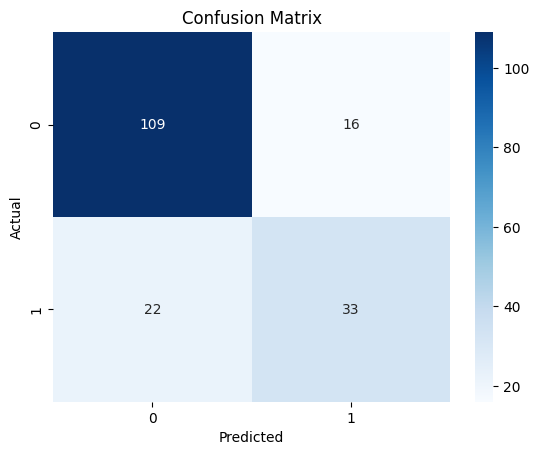

In [6]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted'); plt.ylabel('Actual'); plt.title('Confusion Matrix')
plt.show()


## Takeaways
- Check `model.feature_importances_` — likely satisfaction and overtime_hours dominate.
- The OOB score gives a free sanity check on generalization without touching the test set.
- Next steps: try `GridSearchCV` over `n_estimators`, `max_depth`, `max_features` to squeeze out more performance.

---
# Project 2 — Your Turn
**Dataset:** Digits dataset (`sklearn.datasets.load_digits`) — classify handwritten digit images (0-9) from 64 pixel-intensity features.

```python
from sklearn.datasets import load_digits
data = load_digits()
X = pd.DataFrame(data.data)
y = data.target
```
**Tasks:** train a Random Forest multi-class classifier, check OOB score, tune `n_estimators`/`max_depth`, and visualize a few misclassified digit images.
